In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from nltk.tokenize import word_tokenize
from torch.utils.data import Dataset, DataLoader
import os
import math

In [31]:

if os.path.exists('bukhari.csv'):
    df = pd.read_csv('bukhari.csv', encoding='utf-8')
else:
# الرابط الصحيح
    url = "https://raw.githubusercontent.com/abdelrahmaan/Hadith-Data-Sets/master/All%20Hadith%20Books/Sahih%20Bukhari%20Without_Tashkel.csv"

    # تحميل
    df = pd.read_csv(url, encoding='utf-8')

print(df.head())
print(df.shape)
print(df.columns)

# حفظ محليا
df.to_csv('bukhari.csv', index=False, encoding='utf-8')

df['Sahih Bukhari Without_Tashkel'] = df['Sahih Bukhari Without_Tashkel'].apply(lambda x : " ".join(x.split()[:40]))


                       Sahih Bukhari Without_Tashkel
0  حدثنا الحميدي عبد الله بن الزبير قال حدثنا سفي...
1  حدثنا عبد الله بن يوسف قال أخبرنا مالك عن هشام...
2  حدثنا يحيى بن بكير قال حدثنا الليث عن عقيل عن ...
3  حدثنا موسى بن إسماعيل قال حدثنا أبو عوانة قال ...
4  حدثنا عبدان قال أخبرنا عبد الله قال أخبرنا يون...
(7008, 1)
Index(['Sahih Bukhari Without_Tashkel'], dtype='object')


In [32]:
texts = df['Sahih Bukhari Without_Tashkel'][:400].tolist()
print(texts[0])
print(len(texts[0]))


حدثنا الحميدي عبد الله بن الزبير قال حدثنا سفيان قال حدثنا يحيى بن سعيد الأنصاري قال أخبرني محمد بن إبراهيم التيمي أنه سمع علقمة بن وقاص الليثي يقول سمعت عمر بن الخطاب رضي الله عنه على المنبر قال سمعت رسول
205


In [33]:
joined_text = '\n'.join(texts)

In [34]:
del df,texts

In [35]:
import nltk
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [36]:
tokens = word_tokenize(joined_text)
print(tokens[:10])  # أول 5 نصوص بعد التوكنيزشن

['حدثنا', 'الحميدي', 'عبد', 'الله', 'بن', 'الزبير', 'قال', 'حدثنا', 'سفيان', 'قال']


In [37]:
unique_tokens = sorted(np.unique(tokens))
print(f"Unique tokens len: {len(unique_tokens)}")

Unique tokens len: 2347


In [38]:
word2idx = {word: idx for idx, word in enumerate(unique_tokens)}
idx2word = {idx: word for word, idx in word2idx.items()}

In [39]:
n_words = 10 # Number of words to look at before predicting the next word
sequences = []
next_words = []

for i in range(len(tokens)-n_words):
    sequences.append(tokens[i:i+n_words])
    next_words.append(tokens[i+n_words])

In [40]:
print(sequences[2])
print(next_words[2])

['عبد', 'الله', 'بن', 'الزبير', 'قال', 'حدثنا', 'سفيان', 'قال', 'حدثنا', 'يحيى']
بن


In [41]:
X = np.zeros((len(sequences), n_words,len(unique_tokens)), dtype=bool)
y = np.zeros((len(next_words), len(unique_tokens)), dtype=bool)

for i, sequence in enumerate(sequences):
    for t, word in enumerate(sequence):
        X[i, t, word2idx[word]] = True
    y[i, word2idx[next_words[i]]] = True

In [ ]:
# import torch.nn as nn

# class LSTMTextGenerator(nn.Module):
#     def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=2):
#         super().__init__()
#         self.embedding = nn.Linear(vocab_size, embedding_dim)  # or use nn.Embedding if using token indices
#         self.lstm = nn.LSTM(
#             embedding_dim, 
#             hidden_dim, 
#             num_layers=num_layers, 
#             batch_first=True,
#             dropout=0.3
#         )
#         self.fc = nn.Linear(hidden_dim, vocab_size)
#         # softmax
#         self.softmax = nn.Softmax(dim=-1)
    
#     def forward(self, input_ids, attention_mask=None):
#         x = self.embedding(input_ids)  # (batch, seq_len, embedding_dim)
#         lstm_out, _ = self.lstm(x)  # (batch, seq_len, hidden_dim)
#         logits = self.fc(lstm_out)  # (batch, seq_len, vocab_size)
#         logits = self.softmax(logits)
#         return logits


: 

: 

: 

: 

In [ ]:
import math
import torch.nn.functional as F

BLOCK_SIZE  = 128      
BATCH_SIZE  = 64
N_EMBD      = 256     
N_HEAD      = 8       
N_LAYER     = 6       
DROPOUT     = 0.2
LR          = 3e-4
MAX_ITERS   = 2000    
EVAL_ITERS  = 200
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (B, T, C)
        x = x + self.pe[:x.size(1), :].unsqueeze(0)
        return x

class EncoderTransformer(nn.Module):

    def __init__(self, vocab_size, d_model=N_EMBD, nhead=N_HEAD, num_layers=N_LAYER, dropout=DROPOUT):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=BLOCK_SIZE)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, 
            dropout=dropout, 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, vocab_size)
    
    def generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask.to(DEVICE)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        # Create causal mask ensuring we only look at past tokens
        mask = self.generate_square_subsequent_mask(T)
        
        # Scale embeddings and add positional encoding
        x = self.embedding(idx) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        
        # Pass through the transformer with the causal mask
        try:
            x = self.transformer(x, mask=mask, is_causal=True)
        except TypeError:
            x = self.transformer(x, mask=mask)
            
        logits = self.fc_out(x)
        
        loss = None
        if targets is not None:
            # targets shape should be B*T
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
            
        return logits, loss


In [43]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [44]:
X_indices = np.argmax(X, axis=2)  # Convert one-hot to token indices (batch, seq_len)
dataset = torch.utils.data.TensorDataset(torch.tensor(X_indices, dtype=torch.long), torch.tensor(y, dtype=torch.float32))
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)  # Smaller batch for better convergence

In [ ]:
# del joined_text,sequences,next_words,X,y

: 

: 

: 

: 

In [45]:
# ─── 3. Data Loader ────────────────────────────────────────────────────────────
# Convert token indices and create train/val split
X_indices = np.argmax(X, axis=2)  # Shape: (num_sequences, n_words)

# Flatten all tokens into a single 1D sequence
all_tokens = X_indices.flatten()  # Shape: (num_sequences * n_words,)
all_data = torch.tensor(all_tokens, dtype=torch.long)

# Split into train and val (80/20 split)
split_idx = int(len(all_data) * 0.8)
train_data = all_data[:split_idx]
val_data = all_data[split_idx:]

print(f"Total tokens: {len(all_data)}")
print(f"Train tokens: {len(train_data)}, Val tokens: {len(val_data)}")

def get_batch(split):
    data = train_data if split == "train" else val_data
    ix = torch.randint(len(data) - BLOCK_SIZE, (BATCH_SIZE,))
    x = torch.stack([data[i:i+BLOCK_SIZE]     for i in ix])  # (BATCH_SIZE, BLOCK_SIZE)
    y = torch.stack([data[i+1:i+BLOCK_SIZE+1] for i in ix])  # (BATCH_SIZE, BLOCK_SIZE)
    return x.to(DEVICE), y.to(DEVICE)

Total tokens: 154620
Train tokens: 123696, Val tokens: 30924


In [ ]:
# model = EncoderTransformer(vocab_size=vocab_size).to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

train_loss_history = []
val_loss_history = []
steps_history = []

@torch.no_grad()
def estimate_loss():
    model.eval()
    losses = {}
    for split in ["train", "val"]:
        L = torch.zeros(EVAL_ITERS)
        for k in range(EVAL_ITERS):
            x, y = get_batch(split)
            _, loss = model(x, y)
            L[k] = loss.item()
        losses[split] = L.mean().item()
    model.train()
    return losses

for step in range(MAX_ITERS):
    if step % 200 == 0 or step == MAX_ITERS - 1:
        losses = estimate_loss()
        steps_history.append(step)
        train_loss_history.append(losses['train'])
        val_loss_history.append(losses['val'])
        print(f"Step {step:4d} | train {losses['train']:.4f} | val {losses['val']:.4f}")

    x, y = get_batch("train")
    logits, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()


Parameters: 6,886,491
Step    0 | train 9.2543 | val 9.2737
Step  200 | train 2.8352 | val 4.3675
Step  400 | train 1.4715 | val 4.2903
Step  600 | train 0.9168 | val 4.3431
Step  800 | train 0.7079 | val 4.4263
Step 1000 | train 0.5824 | val 4.5247
Step 1200 | train 0.5030 | val 4.6544
Step 1400 | train 0.4434 | val 4.7039
Step 1600 | train 0.4014 | val 4.7871
Step 1800 | train 0.3691 | val 4.8737
Step 1999 | train 0.3432 | val 4.9416


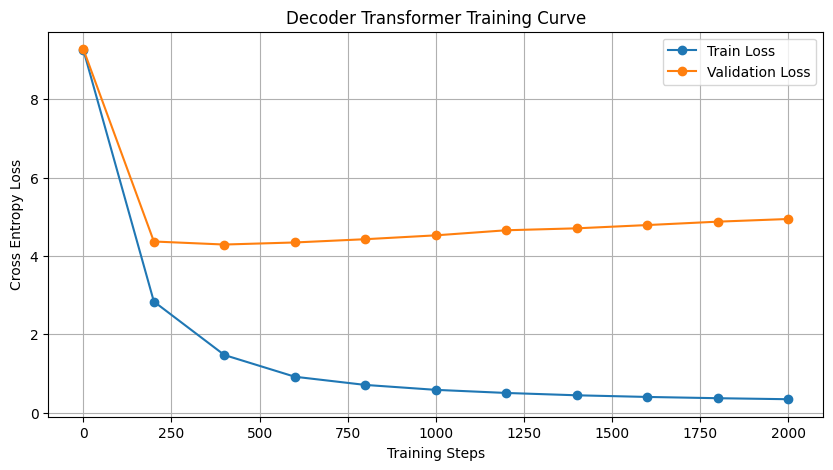

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(steps_history, train_loss_history, label='Train Loss', marker='o')
plt.plot(steps_history, val_loss_history, label='Validation Loss', marker='o')
plt.xlabel('Training Steps')
plt.ylabel('Cross Entropy Loss')
plt.title('Decoder Transformer Training Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
%load_ext tensorboard
%tensorboard --logdir runs

Reusing TensorBoard on port 6007 (pid 16079), started 1:45:19 ago. (Use '!kill 16079' to kill it.)

<IPython.core.display.Javascript object>

: 

: 

In [ ]:
# del dataset,dataloader,criterion,optimizer,num_epochs

: 

: 

In [48]:
torch.save(model.state_dict(), 'transformer_decoder_model.pth')

In [ ]:
# Colab drive mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


: 

: 

In [49]:
# copy the model to drive
!cp transformer_decoder_model.pth /content/drive/MyDrive/transformer_decoder_model.pth

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

: 

: 

In [ ]:
# Load trained DecoderTransformer
vocab_size = len(unique_tokens)
model = DecoderTransformer(vocab_size=vocab_size).to(DEVICE)
try:
    model.load_state_dict(torch.load('transformer_decoder_model.pth', map_location=DEVICE, weights_only=True))
except Exception as e:
    print(f"Information: {e}\nTrain the model, then call torch.save to generate transformer_decoder_model.pth.")
model.eval()

Information: [Errno 2] No such file or directory: 'transformer_decoder_model.pth'
Train the model, then call torch.save to generate transformer_decoder_model.pth.


DecoderTransformer(
  (embedding): Embedding(4187, 256)
  (pos_encoder): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (fc_out): Linear(in_features=256, out_features=4187, bias=True)
)

: 

: 

In [50]:
def predict_next_word(model, input_sequence, word2idx, idx2word, device):
    model.eval()
    with torch.no_grad():
        # Convert words to token indices
        input_ids = []
        for word in input_sequence:
            if word in word2idx:
                input_ids.append(word2idx[word])
        
        if not input_ids:
            return "unk"
        
        # Convert to tensor: (1, seq_len)
        idx = torch.tensor([input_ids], dtype=torch.long).to(device)
        
        # Forward pass
        logits, _ = model(idx)  # (1, seq_len, vocab_size)
        last_logits = logits[0, -1, :]  # (vocab_size,)
        
        # Get most likely token
        predicted_idx = last_logits.argmax().item()
        return idx2word[predicted_idx]

In [51]:
def predict_next_words(model, input_sequence, word2idx, idx2word, device, k=5):
    model.eval()
    with torch.no_grad():
        # Convert words to token indices
        input_ids = []
        for word in input_sequence:
            if word in word2idx:
                input_ids.append(word2idx[word])
        
        if not input_ids:
            return []
        
        # Convert to tensor: (1, seq_len)
        idx = torch.tensor([input_ids], dtype=torch.long).to(device)
        
        # Forward pass
        logits, _ = model(idx)  # (1, seq_len, vocab_size)
        last_logits = logits[0, -1, :]  # (vocab_size,)
        
        # Get top-k predictions
        k = min(k, last_logits.shape[0])
        top_probs, top_indices = torch.topk(last_logits, k=k)
        
        return [(idx2word[int(i)], float(p)) for p, i in zip(top_probs.cpu(), top_indices.cpu())]

In [59]:
test = "قال حدثني مالك "

In [60]:
predict_next_words(model, test.split()[-n_words:], word2idx, idx2word, device)

[(np.str_('عن'), 13.564509391784668),
 (np.str_('بن'), 9.482550621032715),
 (np.str_('قال'), 6.956009387969971),
 (np.str_('.'), 6.670526027679443),
 (np.str_('النبي'), 6.258829116821289)]

In [61]:
for _ in range(10):
    test += predict_next_word(model, test.split()[-n_words:], word2idx, idx2word, device) + " "
print(test)

قال حدثني مالك عن ابن شهاب عن عبيد الله بن عبد الله بن 
